# Projet ML Gym Members analysis python

# Introduction

Ce projet vise à modéliser et analyser le jeu de données "Gym Members Exercise Dataset". L’objectif est de prédire :

    -Les calories brûlées (Calories_Burned) en fonction des autres variables.
    -Le niveau d'expérience (Experience_Level).

### Méthodologie

    -Exploration des données : analyse descriptive et visualisations.
    -Modélisation : comparaison de modèles (régression, SVM, forêts aléatoires, réseaux de neurones) avec optimisation des hyperparamètres.
    -Interprétation : analyse des performances et importance des variables.

Les résultats seront présentés sous forme de notebooks Jupyter et défendus lors d'une soutenance orale.

### Variables
• Age : âge du membre de la salle de sport.

• Gender : Sexe du membre de la salle de sport (qualitative à deux modalités : homme ou femme).

• Weight..kg. : Poids du membre en kilogrammes.

• Height..m. : Taille du membre en mètres.

• Max_BPM : Fréquence cardiaque maximale (battements par minute) pendant les séances d’entraînement.

• Avg_BPM : Fréquence cardiaque moyenne pendant les séances d’entraînement.

• Resting_BPM : Fréquence cardiaque au repos avant l’entraînement.

• Session_Duration..hours. : Durée de chaque séance d’entraînement en heures.

• Calories_Burned : Total des calories brûlées au cours de chaque séance.

• Workout_Type : Type d’entraînement effectué (qualitative à 4 modalités : cardio, musculation, yoga,
HIIT).

• Fat_Percentage (Pourcentage de graisse) : Pourcentage de graisse corporelle du membre.

• Water_Intake..liters. : Consommation quotidienne d’eau pendant les séances d’entraînement.

• Workout_Frequency..days.week. : Nombre de séances d’entraînement par semaine (qualitative à 4
modalités : 2 à 5).

• Experience_Level : Niveau d’expérience (qualitative à 3 modalités : 1 pour débutant à 3 pour expert).

• BMI : Indice de masse corporelle (IMC), calculé à partir de la taille et du poids.

# Analyse exploratoire des données

## Préparation des données

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Lecture des données
gym=pd.read_csv("gym_members_exercise_tracking.csv")
# Vérification du contenu
gym.head()


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [48]:
gym.dtypes

Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

Les variables Gender, Workout_type, Workout_Frequency, Experience_Level sont de type qualitatives, on doit donc modifier leur type pour l'analyse. On change également le type de la variable à analyser : Calories_Burned

In [49]:
gym["Gender"]=pd.Categorical(gym["Gender"],ordered=False)
gym["Workout_Type"]=pd.Categorical(gym["Workout_Type"],ordered=False)
gym["Workout_Frequency (days/week)"]=pd.Categorical(gym["Workout_Frequency (days/week)"],ordered=False)
gym["Experience_Level"]=pd.Categorical(gym["Experience_Level"],ordered=False)
gym["Calories_Burned"]=pd.DataFrame(gym["Calories_Burned"], dtype=float) #variable testée mise en data frame
gym.dtypes

Age                                 int64
Gender                           category
Weight (kg)                       float64
Height (m)                        float64
Max_BPM                             int64
Avg_BPM                             int64
Resting_BPM                         int64
Session_Duration (hours)          float64
Calories_Burned                   float64
Workout_Type                     category
Fat_Percentage                    float64
Water_Intake (liters)             float64
Workout_Frequency (days/week)    category
Experience_Level                 category
BMI                               float64
dtype: object

In [50]:
gym.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,49.840000


#### Y-a-t-il des informations manquantes ? 

In [51]:
gym.isnull().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

## Analyse unidimensionnel 

On observe la distribution de chaque variable.

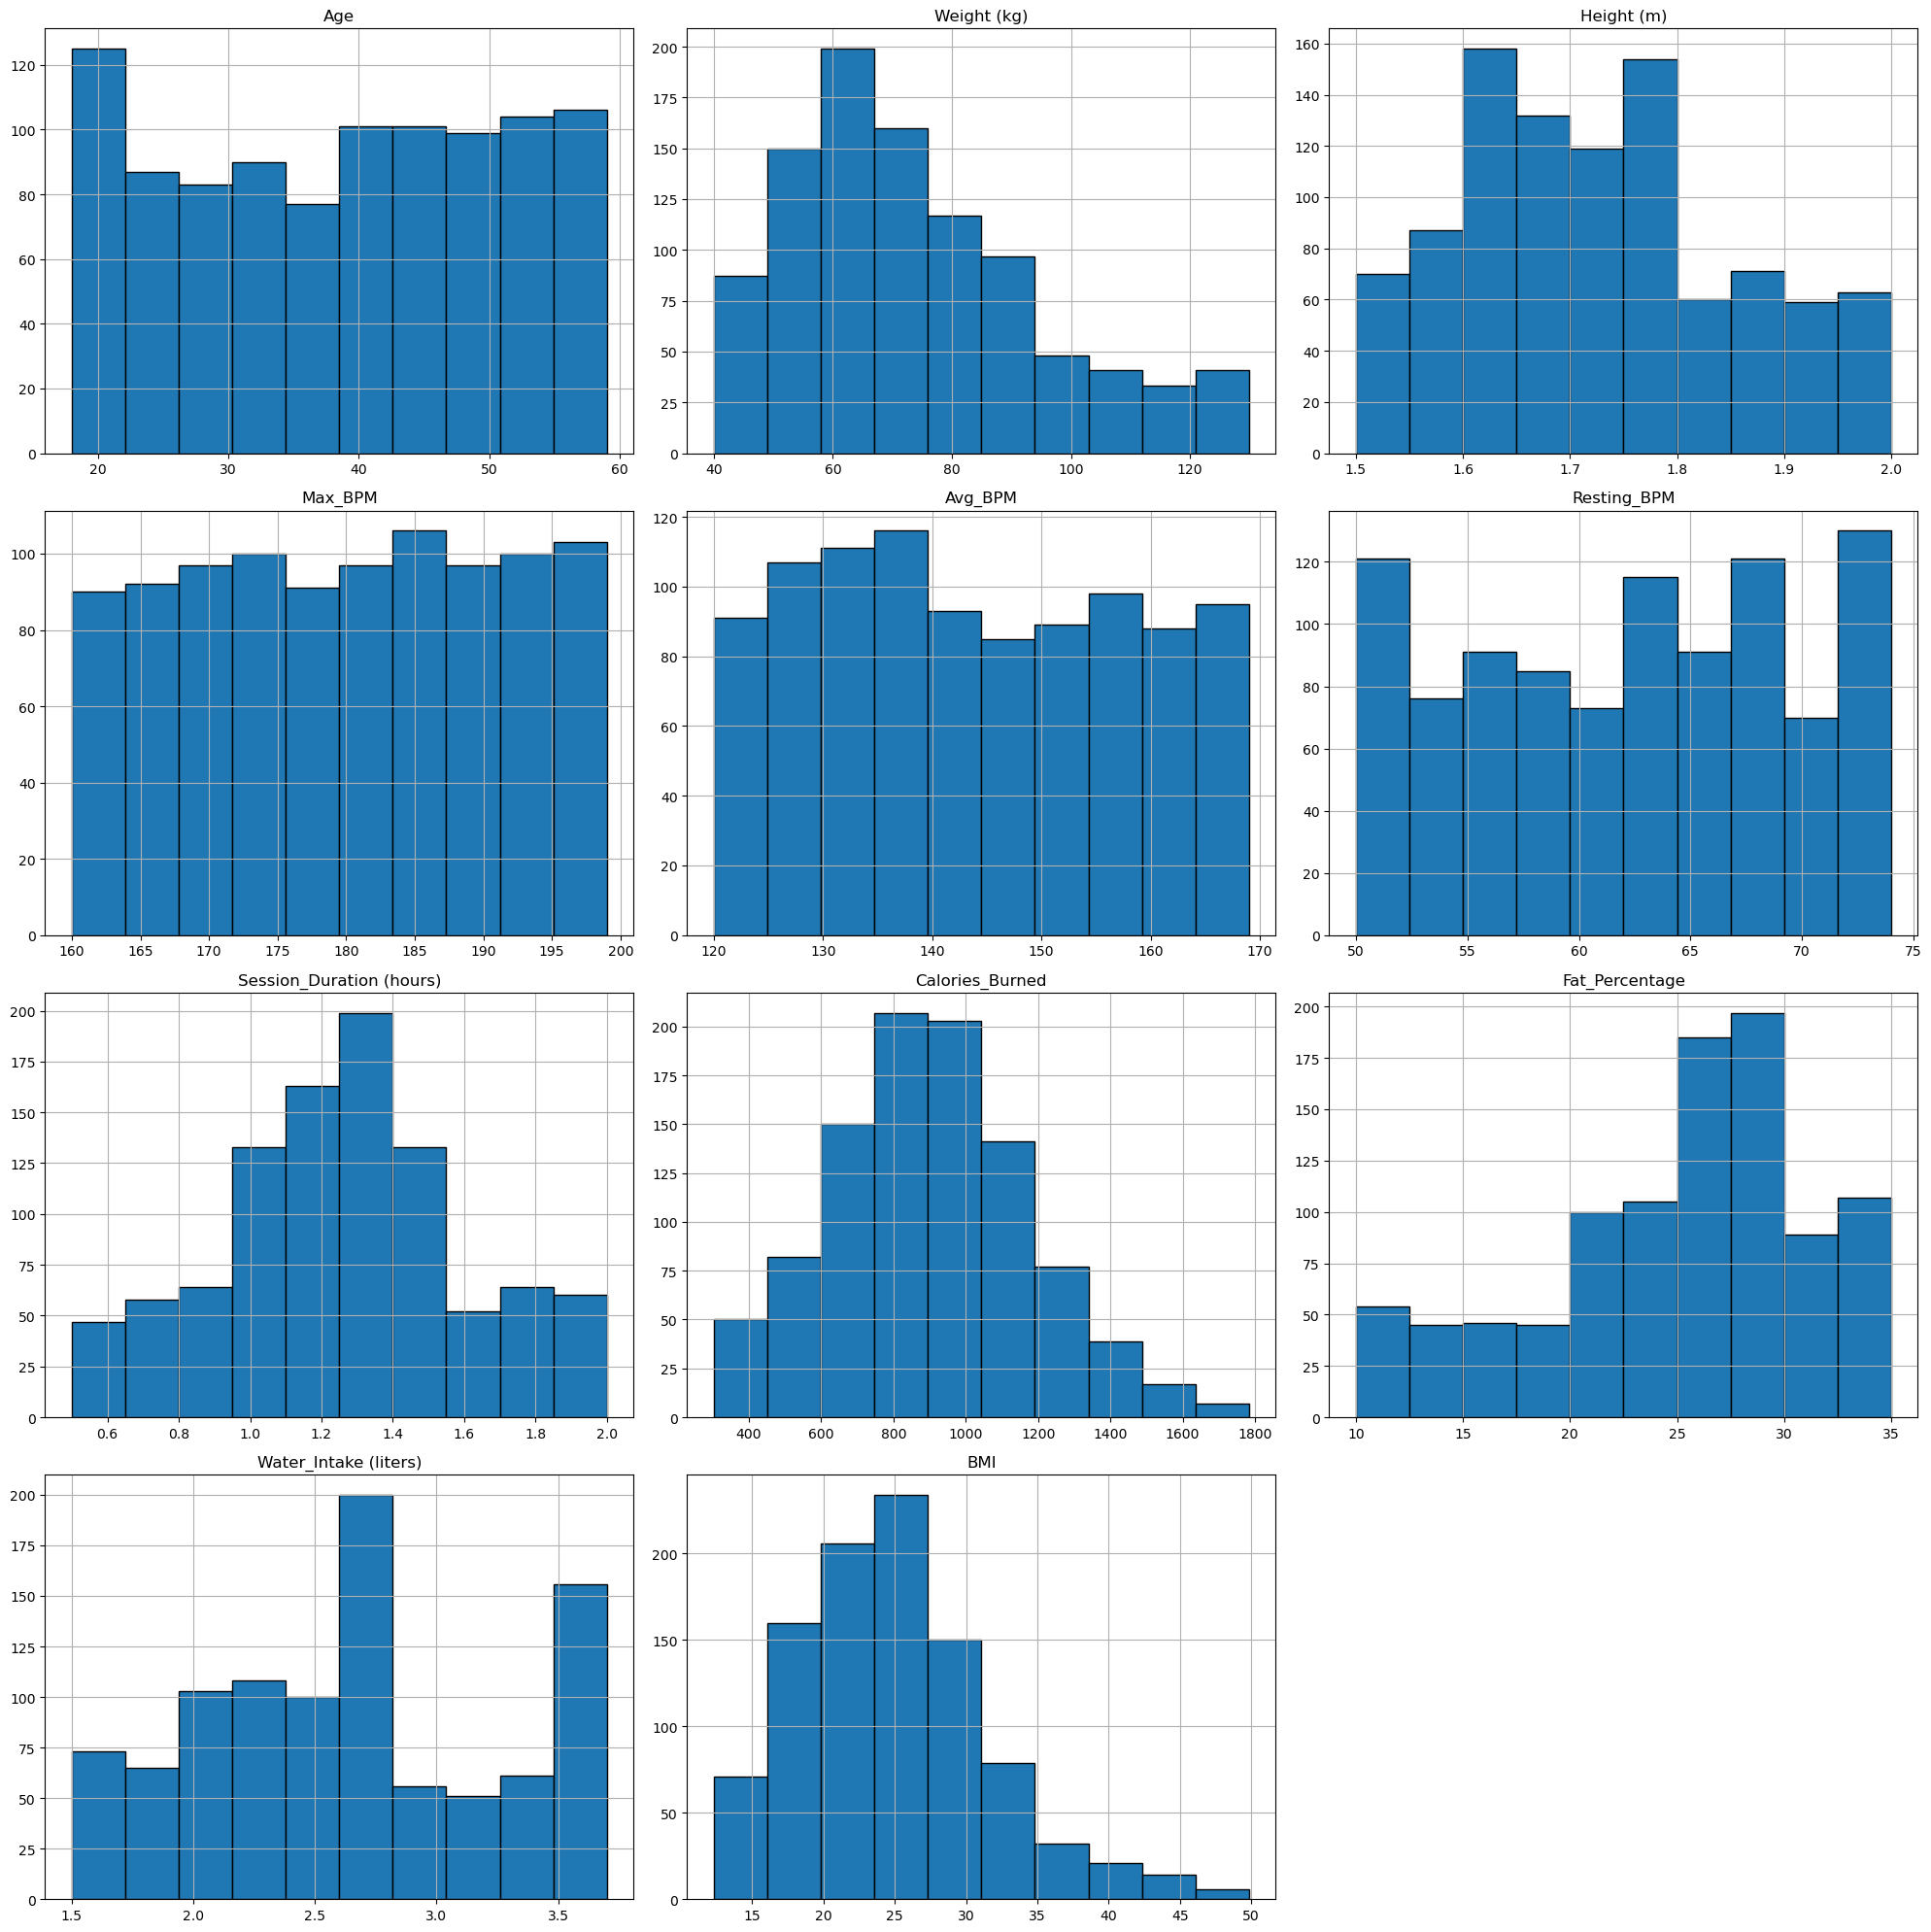

In [52]:
gym.hist(figsize=(20, 20), bins=10, edgecolor="black")

# Afficher les graphiques
plt.tight_layout()
plt.show()

Il semble pertinent d'opérer des transformations sur les variables Weight, BMI

In [53]:
from math import sqrt, log
gym["SWeight (kg)"]=gym["Weight (kg)"].map(lambda x: sqrt(x))
gym["SBMI"]=gym["BMI"].map(lambda x: sqrt(x))
#En linéaire, on explique des données gaussiennes avec d'autres varaibles et donc c'est plus facile avec d'autres variables gaussiennes
#cette transformation peut ne pas être utile 
del gym["Weight (kg)"]
del gym["BMI"] 
gym.head()


,Age,Gender,Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,SWeight (kg),SBMI
0,56,Male,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,9.396808,5.495453
1,46,Female,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,8.654479,5.656854
2,32,Female,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,8.252272,4.970915
3,25,Male,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,7.293833,4.290688
4,38,Male,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,6.789698,3.793415


<Axes: >

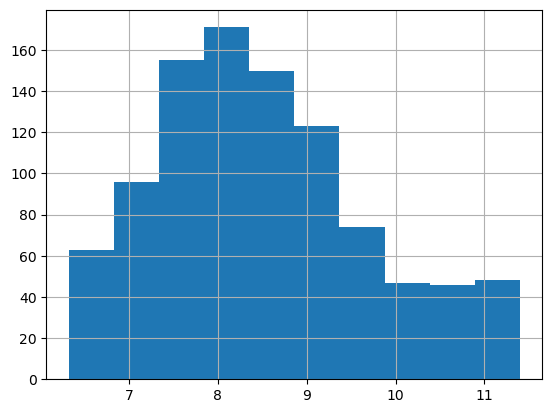

In [54]:
gym["SWeight (kg)"].hist()

<Axes: >

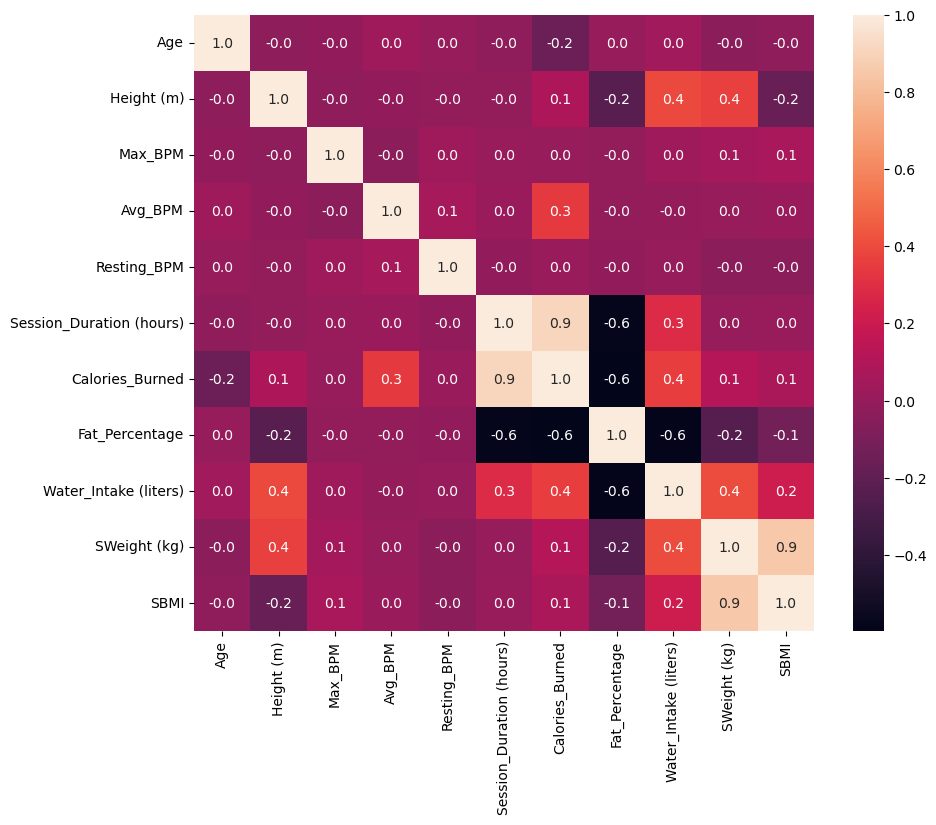

In [61]:
plt.figure(figsize=(10,8))
sns.heatmap(gym.corr(numeric_only=True), annot = True, fmt = '.1f') #fmt fais l'approximation pour avoir que 2 digits

On observe que l'IMC et le poids sont très corrélés (normal car le calcul de l'IMC se fait en fonction du poids), bizzarre, la taille elle n'a pas vraiment d'influence. 
Les calories brulées sont aussi très corrélées à la durée de la séance 
Le pourcentage de gras est assez corrélé à la quantité d'eau bue, la durée de la session et les calories brulées 

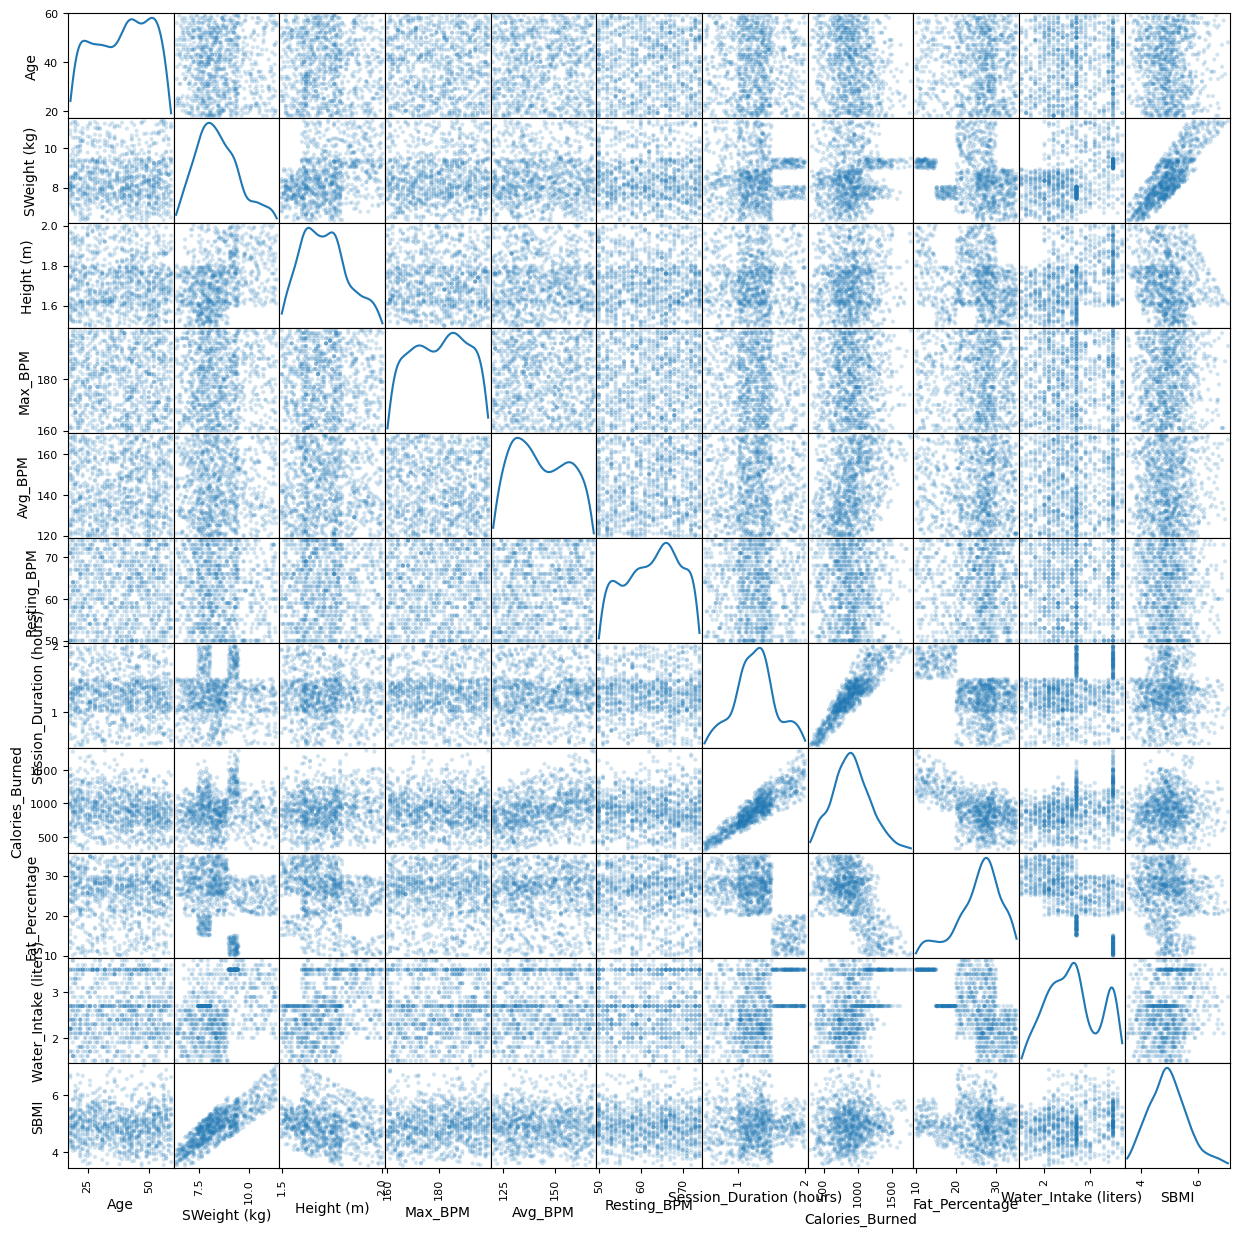

In [58]:
from pandas.plotting import scatter_matrix
scatter_matrix(gym[["Age","SWeight (kg)","Height (m)","Max_BPM","Avg_BPM","Resting_BPM","Session_Duration (hours)","Calories_Burned","Fat_Percentage","Water_Intake (liters)","SBMI"]], alpha=0.2, 
               figsize=(15, 15), diagonal='kde')
plt.show()

Ce graphique nous en dis plus, notamment que les personnes avec un faible taux de masse grasse font uniquement des seesions longues tandis que les personnes plus épaisses dépassent presque jamais les séances de 1h30. Egalement, la quantité d'eau fait des trucs chelou.